# Portfolio Risk & Performance Dashboard

##### Analyses my own DeGiro investment portfolio — reconstructing my actual trading history from raw transaction data, calculating realised and unrealised P/L, and measuring risk (volatility, VaR, Sharpe ratio, max drawdown).

## Holdings

##### Current holdings and cost basis, hardcoded from a DeGiro snapshot. A live price pull via yfinance is planned for v2.

In [7]:
import pandas as pd

transactions = pd.read_csv("Transactions.csv")

holdings = pd.DataFrame({
    "ticker": [ "AMD", "AMZN", "CWEN", "CEG", "DELL", "EQQQ", "FSLR", "JPM", "LITE", "NEE", "TPL"],
    "qty": [16,12,20,21,6,1,9,2,5,23,9],
    "price_local":[560, 240, 34.5, 238, 428, 644, 238, 329, 822, 87, 430 ],
    "bep_local":[197.62, 220.29, 28.46, 305.7, 119.6, 549.4, 218.1,306,148.6,77.4,331.66]   
})



holdings["currency"] = ["USD", "USD", "USD", "USD", "USD", "EUR", "USD", "USD", "USD", "USD", "USD"]
holdings["value_local"] = holdings["price_local"]*holdings["qty"]
holdings["cost_local"] = holdings["bep_local"]*holdings["qty"]
holdings["p/l_local"] = holdings["value_local"] - holdings["cost_local"]

cash_euro = 767.05

### Currency conversion

##### Holdings are priced in a mix of USD and EUR. Converting everything to EUR (the account's reporting currency) so values can be summed and compared directly.

In [8]:
import yfinance as yf

fx = yf.Ticker("EURUSD=X")
euro_usd_rate = fx.info["regularMarketPrice"]

In [10]:
holdings



,ticker,qty,price_local,bep_local,currency,value_local,cost_local,p/l_local
0,AMD,16,560.0,197.62,USD,8960.0,3161.92,5798.08
1,AMZN,12,240.0,220.29,USD,2880.0,2643.48,236.52
2,CWEN,20,34.5,28.46,USD,690.0,569.20,120.80
3,CEG,21,238.0,305.70,USD,4998.0,6419.70,-1421.70
4,DELL,6,428.0,119.60,USD,2568.0,717.60,1850.40
5,EQQQ,1,644.0,549.40,EUR,644.0,549.40,94.60
6,FSLR,9,238.0,218.10,USD,2142.0,1962.90,179.10
7,JPM,2,329.0,306.00,USD,658.0,612.00,46.00
8,LITE,5,822.0,148.60,USD,4110.0,743.00,3367.00
9,NEE,23,87.0,77.40,USD,2001.0,1780.20,220.80


In [11]:
euro_usd_rate

holdings["price_euro"] = holdings.apply(
    lambda row: row["price_local"] / euro_usd_rate if row["currency"]=="USD" else row["price_local"],
    axis=1 #NB tells to go row by row
)
holdings["bep_euro"] = holdings.apply(
    lambda row: row["bep_local"] / euro_usd_rate if row["currency"] == "USD" else row["bep_local"],
    axis=1
)

holdings["value_euro"] = holdings["price_euro"] * holdings["qty"]
holdings["cost_euro"] = holdings["bep_euro"] * holdings["qty"]
holdings["p/l_euro"] = holdings["value_euro"] - holdings["cost_euro"]
holdings["p/l_pct"] = holdings["p/l_euro"] / holdings["cost_euro"] *100


In [12]:
holdings

,ticker,qty,price_local,bep_local,currency,value_local,cost_local,p/l_local,price_euro,bep_euro,value_euro,cost_euro,p/l_euro,p/l_pct
0,AMD,16,560.0,197.62,USD,8960.0,3161.92,5798.08,485.071996,171.178443,7761.151935,2738.855081,5022.296854,183.372128
1,AMZN,12,240.0,220.29,USD,2880.0,2643.48,236.52,207.887998,190.815196,2494.655979,2289.782357,204.873622,8.947297
2,CWEN,20,34.5,28.46,USD,690.0,569.20,120.80,29.883900,24.652052,597.677995,493.041036,104.636959,21.222769
3,CEG,21,238.0,305.70,USD,4998.0,6419.70,-1421.70,206.155598,264.797338,4329.267564,5560.744094,-1231.476530,-22.145895
4,DELL,6,428.0,119.60,USD,2568.0,717.60,1850.40,370.733597,103.597519,2224.401581,621.585115,1602.816467,257.859532
5,EQQQ,1,644.0,549.40,EUR,644.0,549.40,94.60,644.000000,549.400000,644.000000,549.400000,94.600000,17.218784
6,FSLR,9,238.0,218.10,USD,2142.0,1962.90,179.10,206.155598,188.918218,1855.400384,1700.263966,155.136419,9.124255
7,JPM,2,329.0,306.00,USD,658.0,612.00,46.00,284.979798,265.057198,569.959595,530.114396,39.845200,7.516340
8,LITE,5,822.0,148.60,USD,4110.0,743.00,3367.00,712.016394,128.717319,3560.081970,643.586595,2916.495376,453.162853
9,NEE,23,87.0,77.40,USD,2001.0,1780.20,220.80,75.359399,67.043879,1733.266186,1542.009227,191.256958,12.403101


In [13]:
total_portfolio_value = holdings["value_euro"].sum() + cash_euro
total_portfolio_value

29889.107161923446

In [14]:
euro_usd_rate

1.1544678

## Visuals

### Allocation pie chart

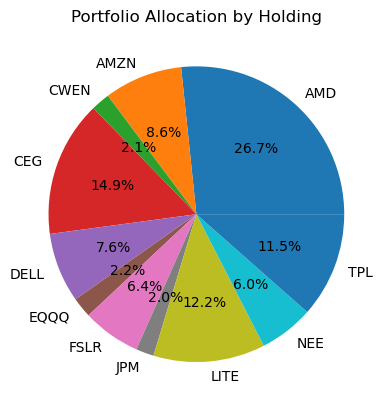

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots() #NB creates a blank canvas
ax.pie(holdings["value_euro"],labels=holdings["ticker"], autopct="%1.1f%%")
ax.set_title("Portfolio Allocation by Holding")
plt.show()

### Returns Bar Chart

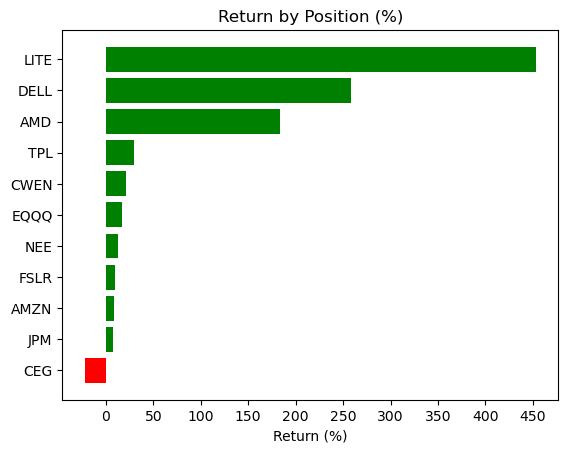

In [19]:
import numpy as np

sorted_holdings = holdings.sort_values("p/l_pct")

colors = ["red" if v < 0 else "green" for v in sorted_holdings["p/l_pct"]]

fig,ax = plt.subplots()
ax.barh(sorted_holdings["ticker"], sorted_holdings["p/l_pct"], color = colors)
ax.set_title("Return by Position (%)")
ax.set_xlabel("Return (%)")
ax.set_xticks(np.arange(0,500,50))
plt.show()

## Transactions

##### Loading and cleaning the DeGiro transaction export. The raw column headers are malformed (blank/duplicate columns), so column names are assigned manually.

In [21]:
transactions = pd.read_csv("Transactions.csv", header = None, skiprows = 1)
transactions.columns = ["date", "time", "product", "isin", " ref_exchange", "venue", "quantity", "price", "price_ccy",
                        "local_value", "local_ccy", "value_euro", "fx_rate", "autofx_fee", "fees_euro", "total_euro", 
                        "order_id", "extra"]
transactions.head()

,date,time,product,isin,ref_exchange,venue,quantity,price,price_ccy,local_value,local_ccy,value_euro,fx_rate,autofx_fee,fees_euro,total_euro,order_id,extra
0,03-03-2026,16:14,NEXTERA ENERGY INC,US65339F1012,NSY,XNAS,7,90.400,USD,-632.80,USD,-547.98,1.1548,-1.37,-2.0,-551.35,NaN,a7d8f8fb-fcc6-4c06-a67e-9dc8907d591d
1,19-02-2026,17:22,CONSTELLATION ENERGY CORP,US21037T1097,NDQ,BATS,2,294.400,USD,-588.80,USD,-500.47,1.1765,-1.25,-2.0,-503.72,NaN,ac8686b3-355b-49a0-b2ee-94fe1eebdab9
2,19-02-2026,17:20,SYMBOTIC INC CLASS A,US87151X1019,NDQ,CDED,-12,55.545,USD,666.54,USD,566.64,1.1763,-1.42,-2.0,563.23,NaN,f86235c9-1582-4aa6-9505-cf8324220ae0
3,11-02-2026,20:11,ADVANCED MICRO DEVICES INC,US0079031078,NDQ,CDED,2,211.360,USD,-422.72,USD,-355.83,1.1880,-0.89,-2.0,-358.72,NaN,99c8b8f3-d811-40db-98f3-9709813ead07
4,11-02-2026,20:10,AMAZON.COM INC,US0231351067,NDQ,XNAS,2,204.500,USD,-409.00,USD,-344.28,1.1880,-0.86,-2.0,-347.14,NaN,f6aff51b-97f8-4d37-bf3d-ca594541d2a8


In [22]:
transactions["date"] = pd.to_datetime(transactions["date"],format="%d-%m-%Y") # real datetime type
transactions.dtypes

date             datetime64[ns]
time                     object
product                  object
isin                     object
 ref_exchange            object
venue                    object
quantity                  int64
price                   float64
price_ccy                object
local_value             float64
local_ccy                object
value_euro              float64
fx_rate                 float64
autofx_fee              float64
fees_euro               float64
total_euro              float64
order_id                 object
extra                    object
dtype: object

In [23]:
net_qty = transactions.groupby("product")["quantity"].sum() # NB for each tciker total of shares traded
print(net_qty)

product
ADR ON ALIBABA GROUP HOLDING LTD             0
ADVANCED MICRO DEVICES INC                  16
ALPHA METALLURGICAL RESOURCES INC            0
ALPHABET INC CLASS A                         0
AMAZON.COM INC                              12
AMUNDI NASDAQ-100 SWAP UCITS ETF EUR ACC     0
CLEARWAY ENERGY INC CLASS C                 20
CONSTELLATION ENERGY CORP                   21
CRANE NXT CO                                 0
DELL TECHNOLOGIES INC CLASS C                6
FIRST SOLAR INC                              9
FORTINET INC                                 0
GRAB HOLDINGS LTD CLASS A                    0
HP INC                                       0
INTUITIVE SURGICAL INC                       0
INVESCO EQQQ NASDAQ-100 UCITS ETF DIST       1
JOHNSON & JOHNSON                            0
JPMORGAN CHASE & CO                          2
LUMENTUM HOLDINGS INC                        5
MICROSOFT CORP                               0
NEXTERA ENERGY INC                          23
NU HO

### Realised p/l

In [25]:
realised_profit = transactions.groupby("product")["total_euro"].sum()
closed_positions = net_qty[net_qty == 0].index
realised_profit[closed_positions]

product
ADR ON ALIBABA GROUP HOLDING LTD            114.19
ALPHA METALLURGICAL RESOURCES INC           -99.55
ALPHABET INC CLASS A                       -294.32
AMUNDI NASDAQ-100 SWAP UCITS ETF EUR ACC     -1.55
CRANE NXT CO                                  8.42
FORTINET INC                               -201.53
GRAB HOLDINGS LTD CLASS A                    -6.66
HP INC                                      -39.10
INTUITIVE SURGICAL INC                     -105.49
JOHNSON & JOHNSON                            -1.53
MICROSOFT CORP                               55.70
NU HOLDINGS LTD. CLASS A                     68.82
OKTA INC CLASS A                           -100.71
PAYPAL HOLDINGS INC                        -102.02
SUPER MICRO COMPUTER INC                   -120.66
SYMBOTIC INC CLASS A                         -6.78
TIDEWATER INC                                35.77
UBER TECHNOLOGIES INC                         6.72
UIPATH INC CLASS A                           88.86
Name: total_euro, dtype

In [27]:
realised_profit[closed_positions].sum()

-701.4200000000009

### Unrealised p/l

In [34]:
total_realised = realised_profit[closed_positions].sum()
total_unrealised = holdings["p/l_euro"].sum()

print(f"Realised P/L (closed trades): €{total_realised:,.2f}")
print(f"Unrealised P/L (open trades): €{total_unrealised:,.2f}")
print(f"Combined: €{total_realised + total_unrealised:,.2f}")

Realised P/L (closed trades): €-701.42
Unrealised P/L (open trades): €9,867.12
Combined: €9,165.70


In [35]:
amd_trades = transactions[transactions["product"] == "ADVANCED MICRO DEVICES INC"].sort_values("date")
amd_trades["running_position"]= amd_trades["quantity"].cumsum()
amd_trades[["date", "quantity", "running_position"]]

,date,quantity,running_position
37,2025-09-12,6,6
13,2025-11-06,1,7
17,2025-11-06,2,9
8,2026-02-04,5,14
3,2026-02-11,2,16


In [36]:
transactions_sorted = transactions.sort_values("date")
transactions_sorted["running_positions"] = transactions_sorted.groupby("product")["quantity"].cumsum()

In [37]:
transactions_sorted[transactions_sorted["product"] == "AMAZON.COM INC"][["date", "quantity", "running_positions"]]

,date,quantity,running_positions
43,2025-09-02,3,3
35,2025-09-23,2,5
14,2025-11-06,2,7
5,2026-02-10,3,10
4,2026-02-11,2,12


In [38]:
transactions_sorted[transactions_sorted["product"]=="CONSTELLATION ENERGY CORP"][["date", "quantity", "running_positions"]]

,date,quantity,running_positions
54,2025-07-16,10,10
33,2025-09-30,2,12
16,2025-11-06,2,14
9,2026-02-03,5,19
1,2026-02-19,2,21


In [39]:
positions = pd.Series(
    [6, 7, 9, 14, 16],   
    index=pd.to_datetime(["2025-09-12", "2025-11-06", "2025-11-06", "2026-02-04", "2026-02-11"])
)

positions_collapsed = positions.groupby(positions.index).last()


all_days = pd.date_range("2025-09-12", "2026-02-11", freq="D")
daily_position = positions_collapsed.reindex(all_days).ffill()
daily_position

2025-09-12     6.0
2025-09-13     6.0
2025-09-14     6.0
2025-09-15     6.0
2025-09-16     6.0
              ... 
2026-02-07    14.0
2026-02-08    14.0
2026-02-09    14.0
2026-02-10    14.0
2026-02-11    16.0
Freq: D, Length: 153, dtype: float64

### Growth Over Time (from transaction history)

##### Reconstructing exact daily share positions from the full trade history, then pricing them with historical data, to build an accurate portfolio value time series — rather than assuming today's holdings applied throughout the whole period.

In [40]:
tickers_held = holdings["ticker"].tolist() # my 11 tickers

#Map DeGiro ticker names to full product names used in the transaction csv
product_names = {
    "AMD" : "ADVANCED MICRO DEVICES INC",
    "AMZN" : "AMAZON.COM INC",
    "CWEN": "CLEARWAY ENERGY INC CLASS C",
    "CEG": "CONSTELLATION ENERGY CORP",
    "DELL": "DELL TECHNOLOGIES INC CLASS C",
    "FSLR": "FIRST SOLAR INC",
    "EQQQ": "INVESCO EQQQ NASDAQ-100 UCITS ETF DIST",
    "JPM": "JPMORGAN CHASE & CO",
    "LITE": "LUMENTUM HOLDINGS INC",
    "NEE": "NEXTERA ENERGY INC",
    "TPL": "TEXAS PACIFIC LAND CORP (DOVER)",
}
all_days = pd.date_range(transactions["date"].min(),pd.Timestamp.today(),freq="D")
daily_positions = pd.DataFrame(index = all_days)

for ticker, product_name in product_names.items():
    ticker_trades = transactions[transactions["product"] == product_name].sort_values("date")
    running = ticker_trades.groupby("date")["quantity"].sum().cumsum()
    daily_positions[ticker] = running.reindex(all_days).ffill().fillna(0)

daily_positions

,AMD,AMZN,CWEN,CEG,DELL,FSLR,EQQQ,JPM,LITE,NEE,TPL
2024-12-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-08,16.0,12.0,20.0,21.0,6.0,9.0,1.0,2.0,5.0,23.0,9.0
2026-08-09,16.0,12.0,20.0,21.0,6.0,9.0,1.0,2.0,5.0,23.0,9.0
2026-08-10,16.0,12.0,20.0,21.0,6.0,9.0,1.0,2.0,5.0,23.0,9.0
2026-08-11,16.0,12.0,20.0,21.0,6.0,9.0,1.0,2.0,5.0,23.0,9.0


In [44]:
import yfinance as yf

yf_tickers = {
     "AMD": "AMD", "AMZN": "AMZN", "CWEN": "CWEN", "CEG": "CEG", "DELL": "DELL",
    "FSLR": "FSLR", "EQQQ": "EQQQ.PA", "JPM": "JPM", "LITE": "LITE",
    "NEE": "NEE", "TPL": "TPL"
}

start = daily_positions.index.min()
end = daily_positions.index.max()

prices = yf.download(list(yf_tickers.values()), start=start, end = end, auto_adjust=True)["Close"]
prices

[*********************100%***********************]  11 of 11 completed


Ticker,AMD,AMZN,CEG,CWEN,DELL,EQQQ.PA,FSLR,JPM,LITE,NEE,TPL
Date,,,,,,,,,,,
2024-12-02,142.059998,210.710007,247.472885,26.820728,122.471657,490.154266,207.919998,237.768906,86.370003,73.692719,495.735077
2024-12-03,141.979996,213.440002,245.420364,26.128996,122.199158,490.651611,207.509995,236.388168,88.699997,72.946899,518.725281
2024-12-04,143.990005,218.160004,252.053864,26.165892,122.724701,494.779358,201.570007,235.017044,94.900002,72.420998,458.586761
2024-12-05,141.360001,220.550003,253.927933,26.396467,121.722267,494.630157,197.929993,237.025421,92.639999,72.860855,444.947357
2024-12-06,138.589996,227.029999,251.488693,26.045990,120.096970,496.669128,194.190002,238.840683,92.839996,71.942909,442.237915
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-05,482.049988,272.649994,265.119995,31.180000,462.700012,628.400024,236.800003,359.239990,826.260010,85.910004,381.880005
2026-08-06,489.279999,272.260010,261.100006,32.849998,437.649994,625.599976,244.139999,356.299988,838.059998,84.599998,355.640015
2026-08-07,483.359985,274.480011,269.890015,32.650002,453.769989,628.299988,250.050003,357.519989,890.169983,84.650002,340.649994


In [50]:
prices = prices.rename(columns={"EQQQ.PA":"EQQQ"})
prices_daily = prices.reindex(daily_positions.index).ffill()

prices_daily.shape
daily_positions.shape

(619, 11)

In [54]:
value_local = daily_positions*prices_daily
value_local.tail()

,AMD,AMZN,CEG,CWEN,DELL,EQQQ,FSLR,JPM,LITE,NEE,TPL
2026-08-08,7733.759766,3293.760132,5667.690308,653.000031,2722.619934,628.299988,2250.450027,715.039978,4450.849915,1946.950035,3065.849945
2026-08-09,7733.759766,3293.760132,5667.690308,653.000031,2722.619934,628.299988,2250.450027,715.039978,4450.849915,1946.950035,3065.849945
2026-08-10,7512.959961,3337.079956,5679.029846,660.999985,2747.280029,628.099976,2153.970016,719.580017,4067.550049,1948.099930,3153.960022
2026-08-11,7589.120117,3267.239868,5679.029846,660.999985,2747.280029,628.099976,2168.190033,724.080017,4067.550049,1972.019951,3284.730011
2026-08-12,7589.120117,3267.239868,5679.029846,660.999985,2747.280029,628.099976,2168.190033,724.080017,4067.550049,1972.019951,3284.730011


In [59]:
fx = yf.download("EURUSD=X", start = start, end = end , auto_adjust = True)["Close"]
fx_daily = fx.reindex(daily_positions.index).ffill()

[*********************100%***********************]  1 of 1 completed


### Portfolio Value

In [61]:
fx_daily = fx_daily.squeeze()

value_eur = value_local.copy()

usd_columns = [ col for col in value_eur.columns if col != "EQQQ"]

for col in usd_columns:
    value_eur[col] = value_eur[col].div(fx_daily,axis=0)

value_eur.tail()

,AMD,AMZN,CEG,CWEN,DELL,EQQQ,FSLR,JPM,LITE,NEE,TPL
2026-08-08,6710.583543,2857.995749,4917.855022,566.608143,2362.417385,628.299988,1952.715545,620.440207,3862.002583,1689.368594,2660.238074
2026-08-09,6710.583543,2857.995749,4917.855022,566.608143,2362.417385,628.299988,1952.715545,620.440207,3862.002583,1689.368594,2660.238074
2026-08-10,6501.114791,2887.642151,4914.178316,571.976531,2377.276456,628.099976,1863.873414,622.667007,3519.732558,1685.729903,2729.184803
2026-08-11,6572.708852,2829.658257,4918.437074,572.472221,2379.336667,628.099976,1877.804225,627.103942,3522.782852,1707.907213,2844.805944
2026-08-12,6572.708852,2829.658257,4918.437074,572.472221,2379.336667,628.099976,1877.804225,627.103942,3522.782852,1707.907213,2844.805944


In [62]:
total_holdings_value = value_eur.sum(axis=1)
total_holdings_value.tail()

2026-08-08    28828.524834
2026-08-09    28828.524834
2026-08-10    28301.475906
2026-08-11    28481.117224
2026-08-12    28481.117224
Freq: D, dtype: float64

In [63]:
cash_eur = 767.05
total_portfolio_value = total_holdings_value + cash_eur
total_portfolio_value.tail()

2026-08-08    29595.574834
2026-08-09    29595.574834
2026-08-10    29068.525906
2026-08-11    29248.167224
2026-08-12    29248.167224
Freq: D, dtype: float64

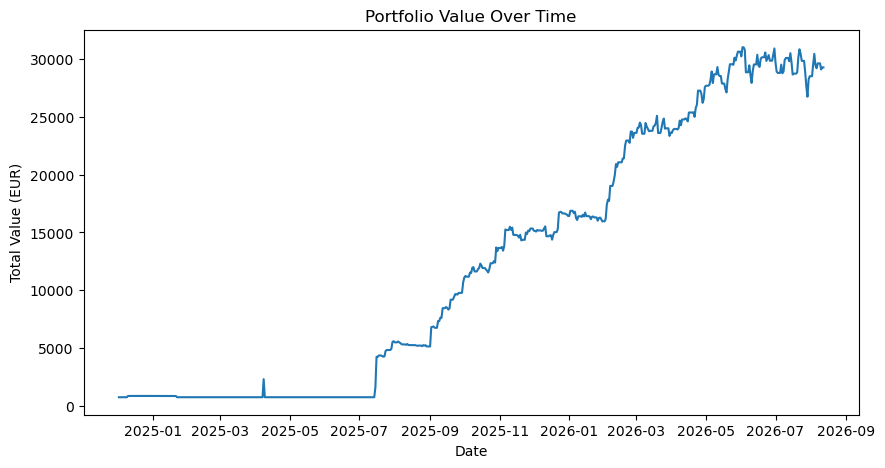

In [64]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(10,5))
ax.plot(total_portfolio_value.index, total_portfolio_value.values)
ax.set_title("Portfolio Value Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Total Value (EUR)")
plt.show()

## Risk Metrics

In [66]:
daily_returns = total_portfolio_value.pct_change().dropna()
daily_returns.tail()

2026-08-08    0.000000
2026-08-09    0.000000
2026-08-10   -0.017808
2026-08-11    0.006180
2026-08-12    0.000000
Freq: D, dtype: float64

In [68]:
import numpy as np

daily_vol = daily_returns.std()
annualised_vol = daily_vol * np.sqrt(252)

print(f"Daily volatility: {daily_vol*100:.2f}%")
print(f"Annualised volatility: {annualised_vol*100: .2f}%")

Daily volatility: 11.94%
Annualised volatility:  189.52%


##### Annualised volatility scales daily volatility by √252 (trading days per year) — volatility scales with the square root of time, not time directly.

In [72]:
### Finding biggest single day swings
daily_returns.sort_values(ascending=False).head(10)

2025-04-08    2.033195
2025-07-16    1.651386
2025-07-15    1.091268
2025-09-02    0.322702
2024-12-10    0.140389
2025-07-30    0.123265
2025-07-24    0.111614
2025-09-12    0.108711
2025-10-29    0.106162
2025-11-06    0.104715
dtype: float64

This is a genuinely important distinction in real performance measurement: your portfolio's volatility should reflect how your investments moved, not how much new cash you poured in. Professionals actually have a formal name for this problem — the difference between "money-weighted return" (distorted by cash flows, like what you just calculated) and "time-weighted return" (the true underlying investment performance). You've just discovered, hands-on, exactly why that distinction exists — that's a genuinely good thing to be able to explain in an interview.

In [78]:
invested_period = total_portfolio_value["2025-07-20":]

daily_returns_clean = invested_period.pct_change().dropna()

daily_returns_clean.sort_values(ascending=False).head(5)


2025-09-02    0.322702
2025-07-30    0.123265
2025-07-24    0.111614
2025-09-12    0.108711
2025-10-29    0.106162
dtype: float64

In [82]:
annualised_vol_clean = daily_returns_clean.std()*np.sqrt(252)
print(f"Annualised volatitlity ( invested period only): {annualised_vol_clean*100:.2f}%")

Annualised volatitlity ( invested period only): 44.89%


Volatility is calculated on daily portfolio returns from the point the portfolio became substantively invested (July 2025), to avoid distortion from the initial cash-heavy period. This measure still contains some noise from days where new capital was added, since separating "market movement" from "money I personally added" (a proper cash-flow-adjusted / time-weighted return) would require more complex reconstruction than this v1 attempts.

In [85]:
sharpe_approx = (daily_returns_clean.mean() * 252 ) / annualised_vol_clean

var_95 = np.percentile(daily_returns_clean, 5 ) * total_portfolio_value.iloc[-1]

max_drawdown = ((invested_period / invested_period.cummax()) -1).min()

print(f"Approx. Sharpe Ratio: {sharpe_approx:.2f}")
print(f"1-day 95% VaR: EUR { abs(var_95):,.0f}")
print(f"Max drawdown: {max_drawdown*100:.1f}%")

Approx. Sharpe Ratio: 2.96
1-day 95% VaR: EUR 787
Max drawdown: -13.8%


##### Sharpe ratio = return per unit of risk taken. VaR = expected loss on a bad day (worst 5%). Max drawdown = largest peak-to-trough decline over the period.